<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code?scriptVersionId=350622387" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #062c22 0%, #024a37 50%, #011f18 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #059669;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #10b981; color: #022c22; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 49</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🌲 Random Forest Classifier</h1>
  <p style="color: #a7f3d0; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">"Combine weak decision trees through variance reduction to build a robust ensemble."</p>
  <p style="color: #6ee7b7; font-size: 15px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">From Bootstrap Aggregation (Bagging) and feature subsampling to Out-of-Bag (OOB) scoring and GridSearchCV hyperparameter optimization — a complete guide to Random Forest.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #059669; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #10b981; font-size: 20px; font-weight: 700;">Bagging</div>
      <div style="color: #a7f3d0; font-size: 12px; margin-top: 2px;">Bootstrap Sampling</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #059669; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #10b981; font-size: 20px; font-weight: 700;">Feature Subspace</div>
      <div style="color: #a7f3d0; font-size: 12px; margin-top: 2px;">Random Feature Selection</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #059669; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #10b981; font-size: 20px; font-weight: 700;">OOB Score</div>
      <div style="color: #a7f3d0; font-size: 12px; margin-top: 2px;">Built-in Validation Metric</div>
    </div>
  </div>
</div>

<div style="background: #011f18; border-left: 5px solid #10b981; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #059669;">
  <h2 style="color: #10b981; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #34d399; line-height: 2.1; font-size: 14px;">
      <li><a href='#intro' style='color: #34d399; text-decoration: none;'>What is Random Forest?</a></li>
      <li><a href='#intuition' style='color: #34d399; text-decoration: none;'>The Core Intuition</a></li>
      <li><a href='#bagging' style='color: #34d399; text-decoration: none;'>Bootstrap Aggregation (Bagging)</a></li>
      <li><a href='#subspace' style='color: #34d399; text-decoration: none;'>Random Feature Subsampling</a></li>
      <li><a href='#oob' style='color: #34d399; text-decoration: none;'>Out-Of-Bag (OOB) Score</a></li>
      <li><a href='#hyperparams' style='color: #34d399; text-decoration: none;'>Key Hyperparameters</a></li>
    </ol>
    <ol start="7" style="margin: 0; padding-left: 20px; color: #34d399; line-height: 2.1; font-size: 14px;">
      <li><a href='#setup' style='color: #34d399; text-decoration: none;'>Imports &amp; Dataset Generation</a></li>
      <li><a href='#rf-model' style='color: #34d399; text-decoration: none;'>Single Tree vs. Random Forest</a></li>
      <li><a href='#boundaries' style='color: #34d399; text-decoration: none;'>Decision Boundary Comparison</a></li>
      <li><a href='#importance' style='color: #34d399; text-decoration: none;'>Feature Importance Analysis</a></li>
      <li><a href='#tuning' style='color: #34d399; text-decoration: none;'>GridSearchCV Hyperparameter Tuning</a></li>
      <li><a href='#eval' style='color: #34d399; text-decoration: none;'>Final Model Evaluation</a></li>
    </ol>
  </div>
</div>

<a id='intro'></a>
<div style="border-bottom: 2px solid #10b981; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #10b981; color: #022c22; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #ecfdf5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📌 What is Random Forest?</h2>
</div>

**Random Forest** is an ensemble supervised machine learning algorithm developed by Leo Breiman and Adele Cutler. It constructs an ensemble of decision trees trained on randomized subsets of the data and aggregates their individual predictions to achieve superior accuracy and generalization.

<div style="background: #011f18; border: 1px solid #059669; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="color: #a7f3d0; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">The Core Idea</div>
  <div style="color: #ecfdf5; font-size: 18px; font-family: Georgia, serif; text-align: center; margin-bottom: 14px; font-weight: 600;">
    Combine predictions from <span style="color: #10b981;">multiple decorrelated decision trees</span> to reduce variance without increasing bias.
  </div>
  <div style="color: #6ee7b7; font-size: 13px; line-height: 1.7; text-align: center;">
    Individual decision trees are prone to high variance and overfitting. Random Forest overcomes this limitation by taking a majority vote (classification) or average (regression) over many decorrelated trees.
  </div>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import make_classification, make_circles
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])

df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.899346,-1.671933,-0.913600,0.140217,1.269139,1
1,0.625428,2.157214,-1.104231,-0.584482,-1.807774,0
2,0.916070,0.819429,0.916636,-0.013500,1.779069,1
3,3.270777,0.735940,-2.871572,-2.084051,1.632801,1
4,0.198467,-0.919717,-5.230202,3.896266,-0.668059,0


In [4]:
# function for row sampling

def sample_rows(df, percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling

def sample_features(df, percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [6]:
# function for combined sampling

def combined_sampling(df, row_percent, col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [7]:
df1 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [8]:
df2 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [9]:
df3 = combined_sampling(df, 0.5, 0.5)

/tmp/ipykernel_16/1014091696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'col5', 'target'], dtype='object')
Index(['col3', 'col1', 'target'], dtype='object')


In [11]:
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = DecisionTreeClassifier(random_state=42)

In [12]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier(random_state=42)

[Text(0.375, 0.9, 'x[1] <= -0.954\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.25, 0.7, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.3125, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[0] <= 0.698\ngini = 0.367\nsamples = 33\nvalue = [8, 25]'),
 Text(0.4375, 0.8, '  False'),
 Text(0.25, 0.5, 'x[0] <= 0.198\ngini = 0.077\nsamples = 25\nvalue = [1, 24]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 21\nvalue = [0, 21]'),
 Text(0.375, 0.3, 'x[0] <= 0.278\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.75, 0.5, 'x[1] <= 2.055\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.625, 0.3, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

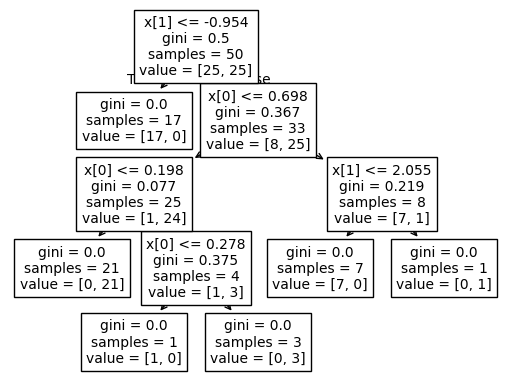

In [13]:
from sklearn.tree import plot_tree

plot_tree(clf1)

[Text(0.5555555555555556, 0.9, 'x[0] <= -0.181\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.3333333333333333, 0.7, 'x[1] <= -0.634\ngini = 0.252\nsamples = 27\nvalue = [4, 23]'),
 Text(0.4444444444444444, 0.8, 'True  '),
 Text(0.2222222222222222, 0.5, 'x[1] <= -1.511\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.1111111111111111, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.3333333333333333, 0.3, 'x[0] <= -0.661\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2222222222222222, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.5, 'gini = 0.0\nsamples = 22\nvalue = [0, 22]'),
 Text(0.7777777777777778, 0.7, 'x[0] <= 0.53\ngini = 0.159\nsamples = 23\nvalue = [21, 2]'),
 Text(0.6666666666666667, 0.8, '  False'),
 Text(0.6666666666666666, 0.5, 'x[1] <= -0.493\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.5555555555555556, 0.3, 'gini = 0.0\nsamples = 4

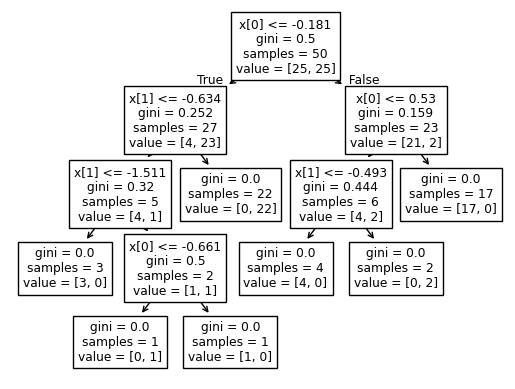

In [14]:
plot_tree(clf2)

[Text(0.5, 0.9375, 'x[1] <= -0.483\ngini = 0.461\nsamples = 50\nvalue = [18, 32]'),
 Text(0.4, 0.8125, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.45, 0.875, 'True  '),
 Text(0.6, 0.8125, 'x[0] <= -3.277\ngini = 0.343\nsamples = 41\nvalue = [9, 32]'),
 Text(0.55, 0.875, '  False'),
 Text(0.5, 0.6875, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7, 0.6875, 'x[1] <= 0.69\ngini = 0.266\nsamples = 38\nvalue = [6, 32]'),
 Text(0.6, 0.5625, 'x[0] <= -0.19\ngini = 0.444\nsamples = 18\nvalue = [6, 12]'),
 Text(0.4, 0.4375, 'x[1] <= 0.585\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.3, 0.3125, 'x[0] <= -1.904\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.2, 0.1875, 'x[1] <= 0.065\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.1, 0.0625, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.3, 0.0625, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4, 0.1875, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.5, 0.3125, 'gini = 0.0\nsamples = 1\nvalue 

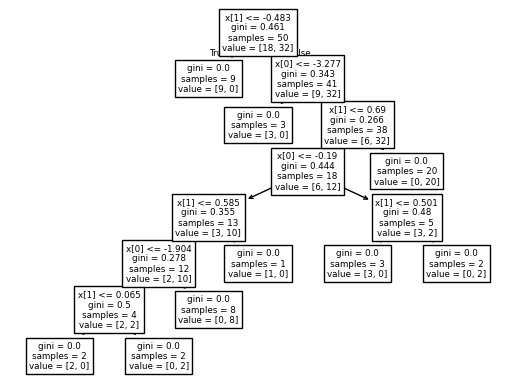

In [15]:
plot_tree(clf3)

In [16]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [17]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [18]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

# Random Forest Demo

In [19]:
np.random.seed(42)

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

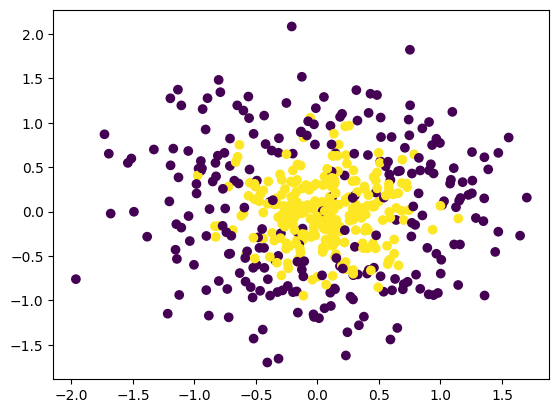

In [20]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

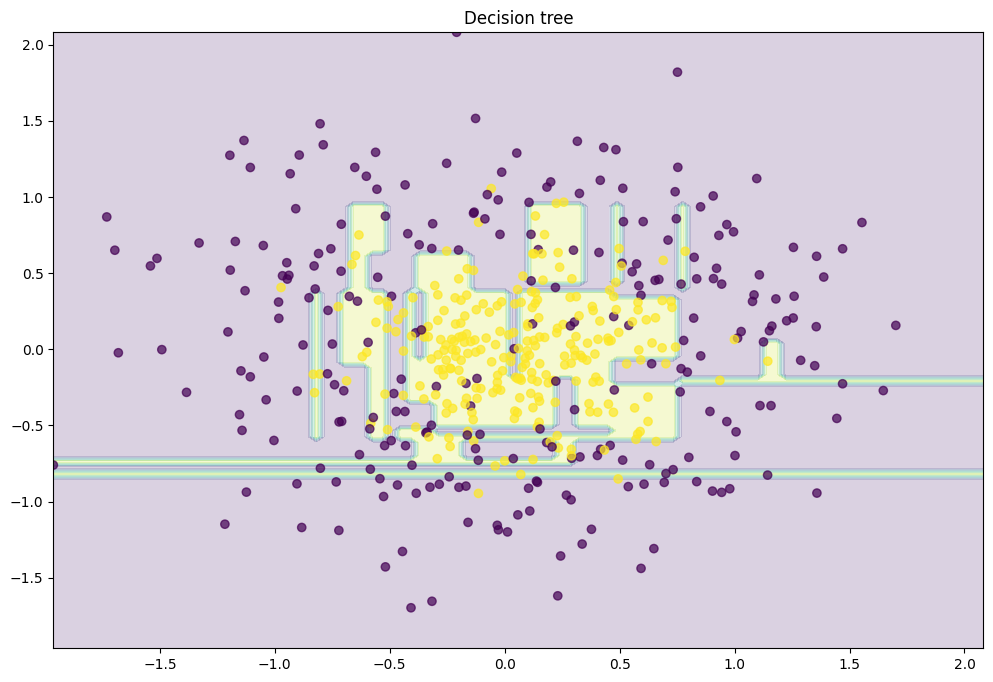

In [21]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()

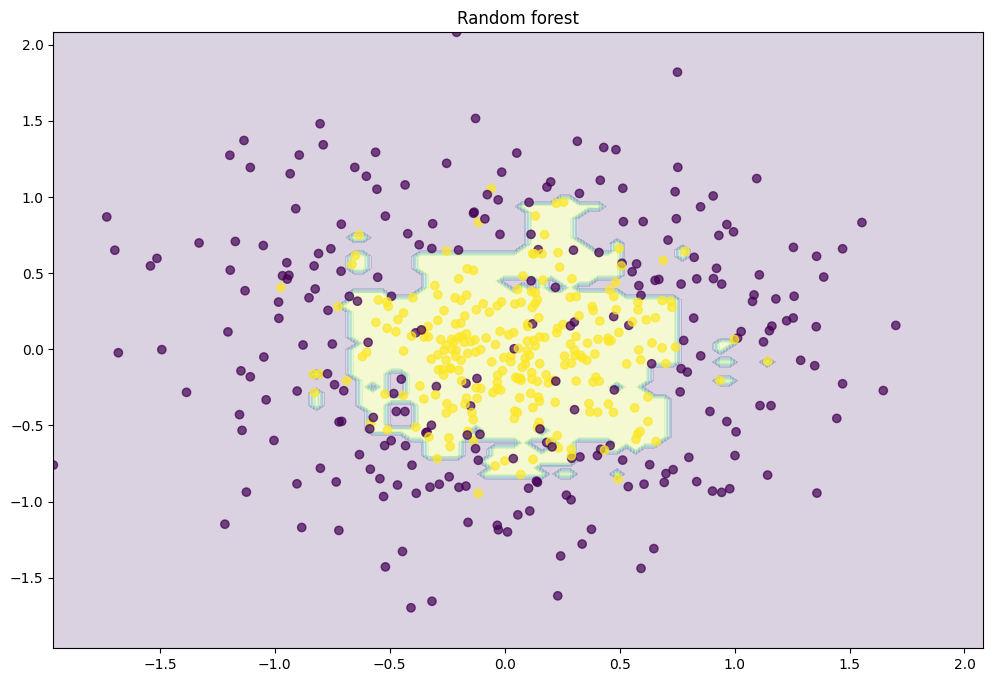

In [22]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

In [23]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

In [24]:
X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

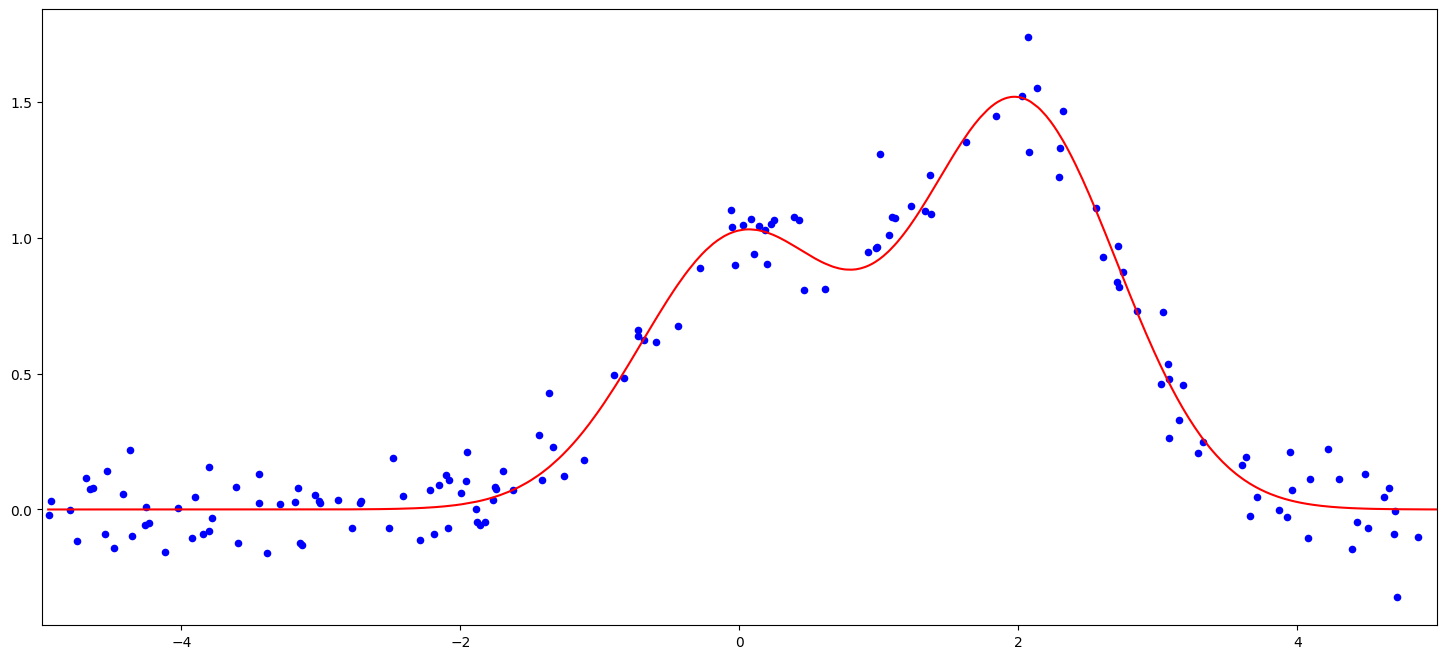

In [25]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])
plt.show()

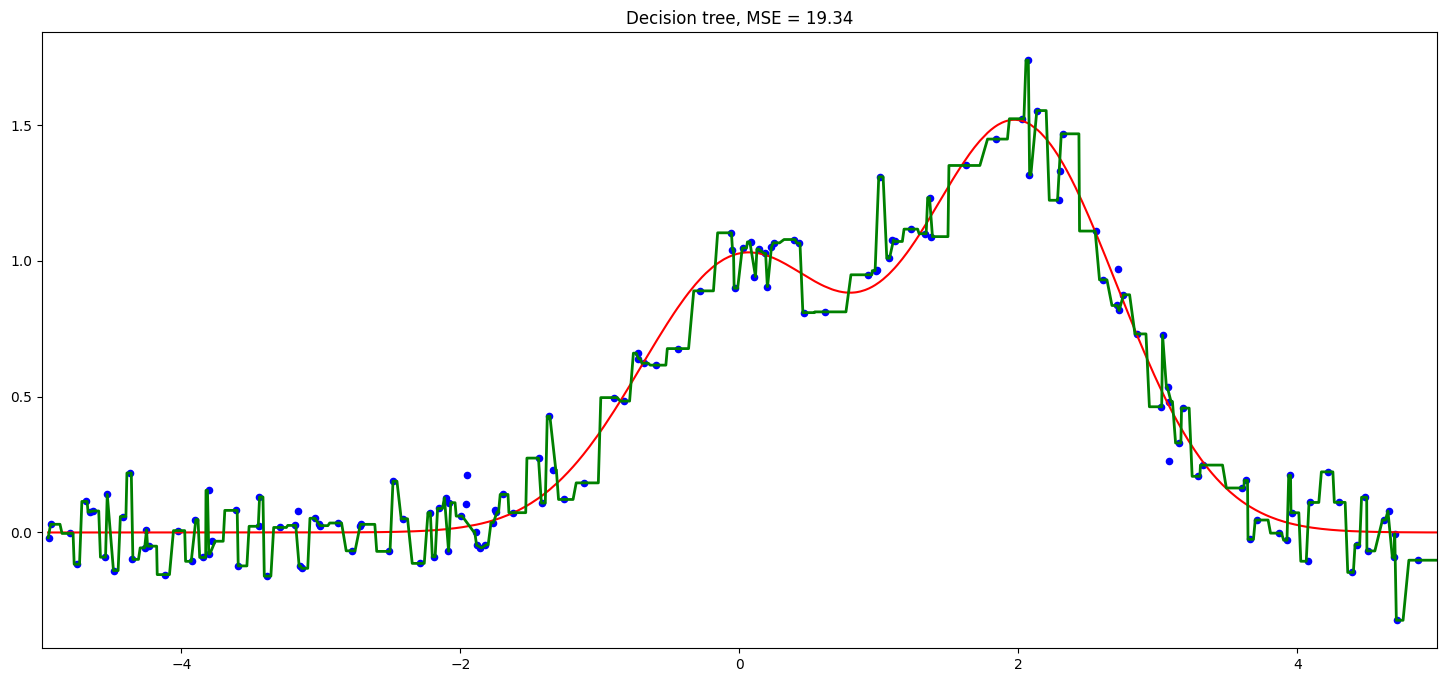

In [26]:
dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))
plt.show()

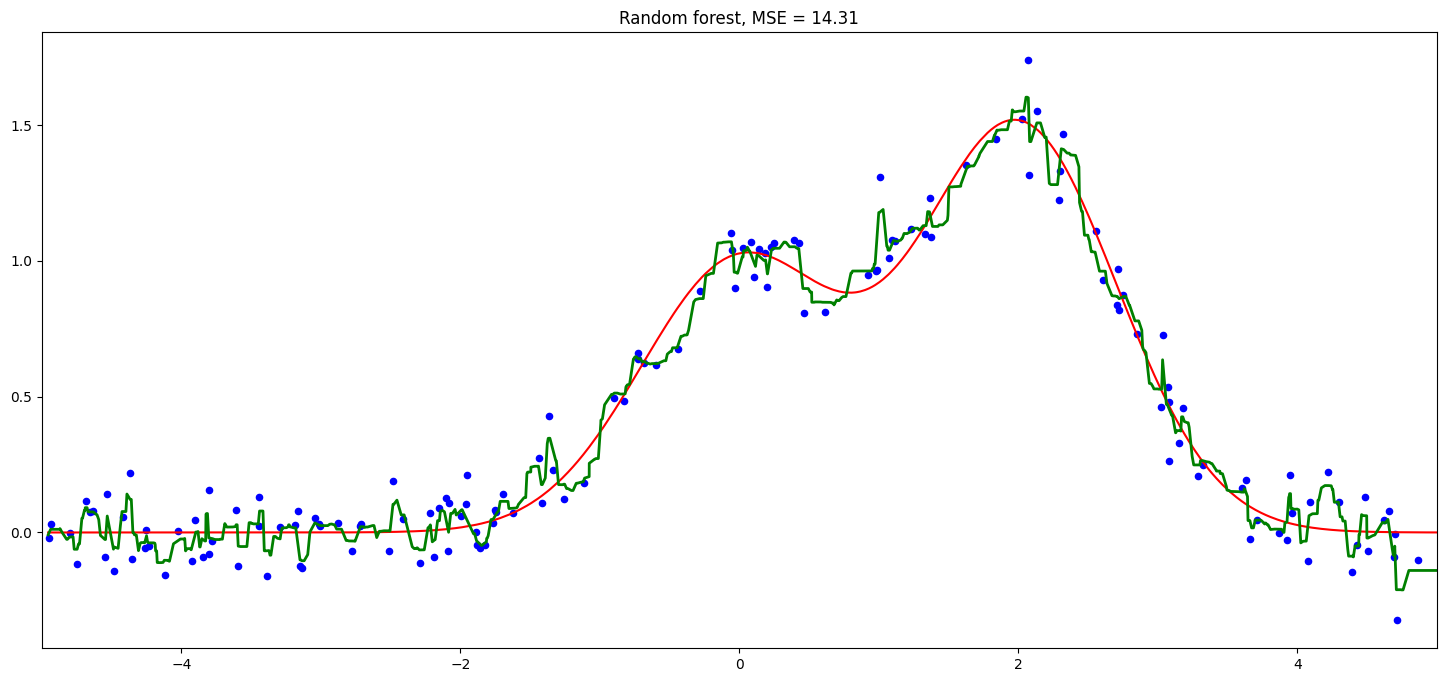

In [27]:
rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2))
plt.show()

# Bagging Vs Random Forest

* Bagging -> Tree Based ...
* Random Forest -> Node Based ...

In [28]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [29]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.524379,-0.239080,0.304957,0.267119,-0.889149,0
1,0.818277,-2.156742,0.246023,0.111282,-0.710882,1
2,0.677754,-1.778875,-1.273572,2.080113,2.538501,0
3,1.190280,-2.725063,1.159571,-1.587152,-0.978871,0
4,-0.319797,-2.323768,-0.476165,-1.553751,0.377498,1


In [30]:
bag = BaggingClassifier(max_features=2)

bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

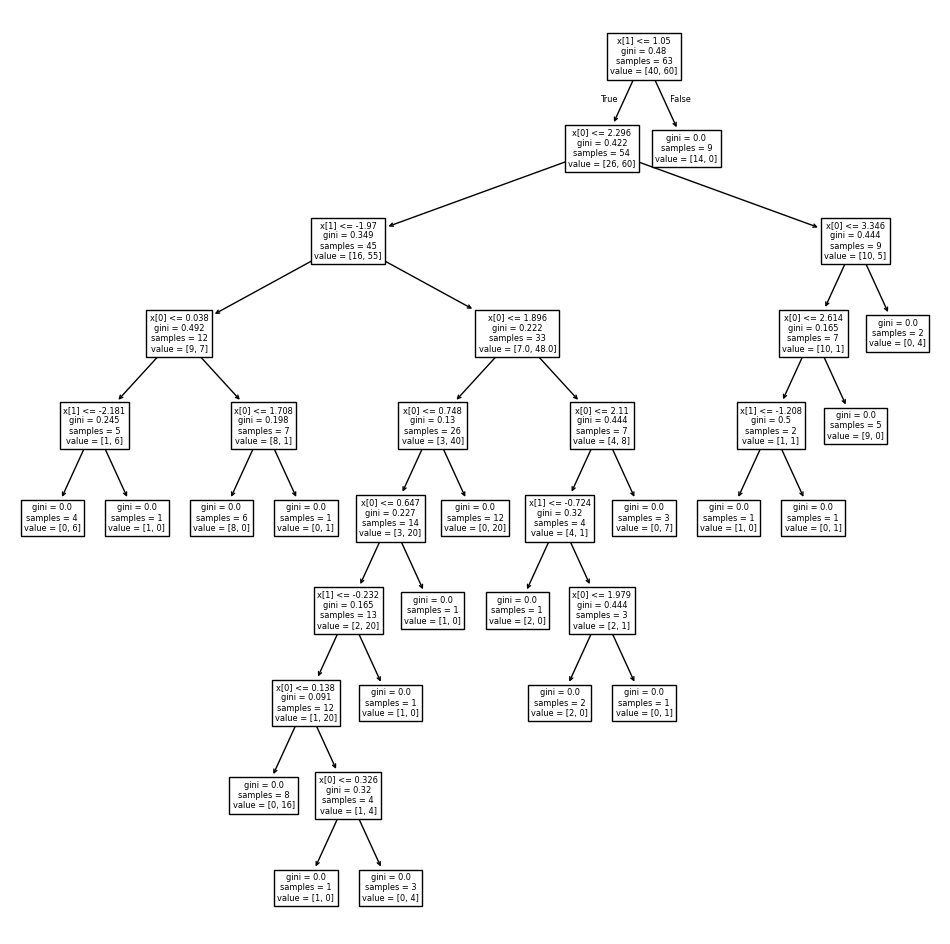

In [31]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [32]:
rf = RandomForestClassifier(max_features=2)

rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

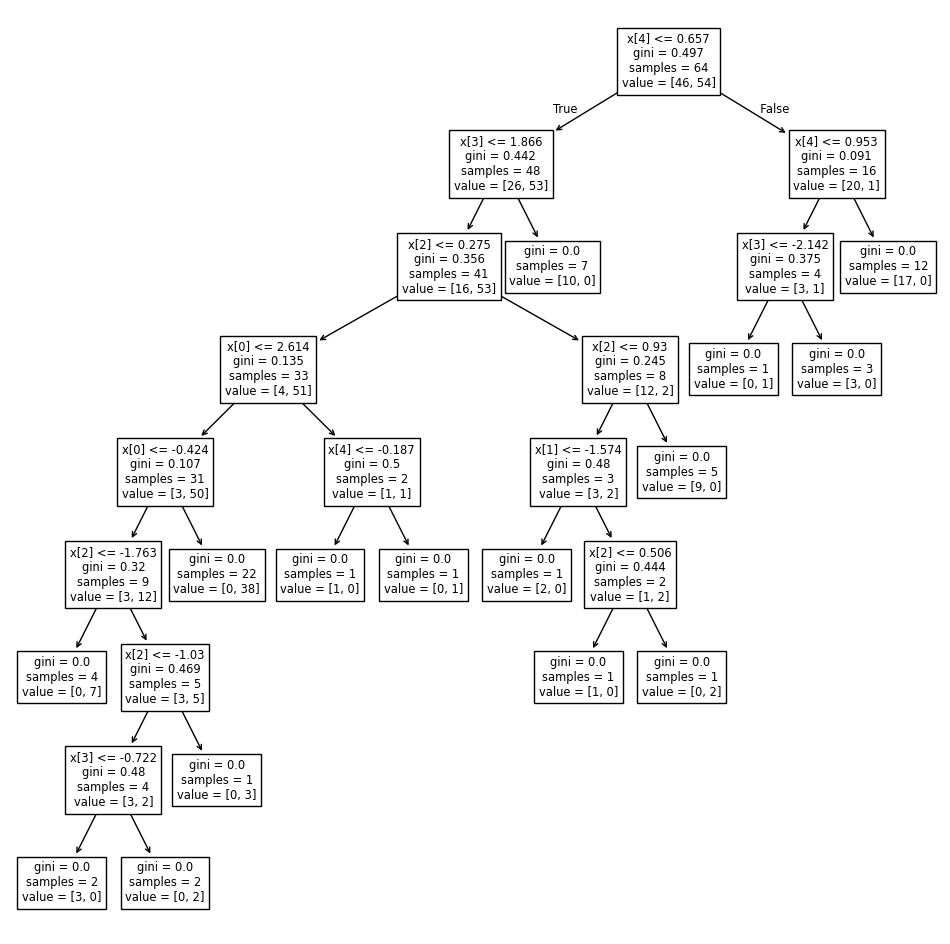

In [33]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()

# Hyperparameter Tuning

In [34]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [35]:
X = df.drop(columns={"target"})
y = df.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [36]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()
lr = LogisticRegression(max_iter=1000)

In [37]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [38]:
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)
accuracy_score(y_test,y_pred)

0.9317073170731708

In [39]:
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test,y_pred)

0.6829268292682927

In [40]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.7951219512195122

This shows that `RandomForestClassifier` gives best result withour `hyperparameter tuning`

In [41]:
rf = RandomForestClassifier(max_samples=0.75, random_state=42)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

In [42]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(rf,X,y,cv=10,scoring='accuracy'))

np.float64(0.9941462021701885)

# GridSearchCV

In [43]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

In [44]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }

In [45]:
rf = RandomForestClassifier()

from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf, 
                       param_grid = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=20; total time=   0.1s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=60; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=100; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=100; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.5, n_estimators=120; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=60; total time=   0.2s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=100; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=120; total time=   0.4s
[CV] END max_depth=2, max_features=0.2, max_samples=0.75, n_estimators=120; total time=   0.3s
[CV] END max_depth=2, max_features=0.2, max_samples=1.0, n_estimators=60; total time=   0.

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [46]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.2,
 'max_samples': 1.0,
 'n_estimators': 60}

In [47]:
rf_grid.best_score_

np.float64(0.9841463414634146)

# RandomSearchCV

In [48]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,None]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

In [49]:
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }

In [50]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf, 
                       param_distributions = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)

rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, None],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [51]:
rf_grid.best_params_

{'n_estimators': 20,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_samples': 1.0,
 'max_features': 1.0,
 'max_depth': None,
 'bootstrap': True}

In [52]:
rf_grid.best_score_

np.float64(0.9817073170731707)

# OOB Score | Out of Bag Evaluation

In [53]:
rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train,y_train)

RandomForestClassifier(oob_score=True)

In [54]:
rf.oob_score_

0.9951219512195122

In [55]:
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9853658536585366

# Feature Importance Using Random Forest

In [56]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
X = df.drop(columns=["label"])
y = df.label

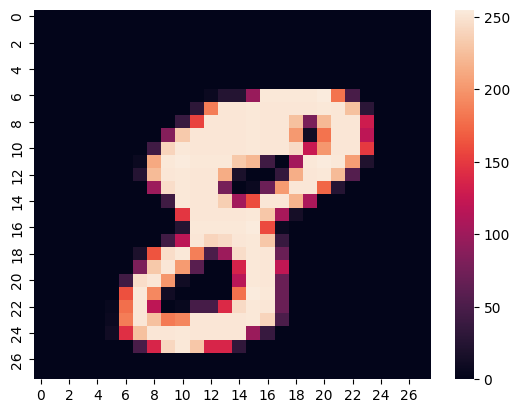

In [58]:
sns.heatmap(X.iloc[10].values.reshape(28,28))
plt.show()

In [59]:
rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [60]:
rf.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.89964299e-07, 1.01132350e-06,
       1.01690211e-05, 6.17553659e-06, 1.94412324e-06, 3.01193066e-06,
       2.51168792e-06, 3.74950975e-07, 2.70646411e-06, 2.34578405e-06,
       3.79461603e-06, 2.52783963e-06, 5.02825697e-07, 4.79048223e-07,
       0.00000000e+00, 1.74155786e-06, 1.56112583e-06, 5.17714880e-07,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

<Axes: >

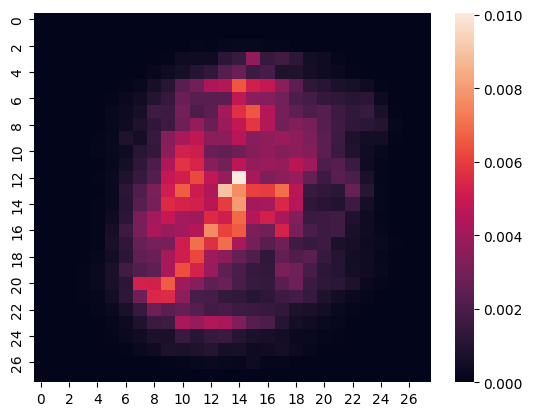

In [61]:
sns.heatmap(rf.feature_importances_.reshape(28,28))

# How Feature Importance Is Calculated

In [62]:
X,y = make_classification(n_samples=5, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)

In [63]:
clf = DecisionTreeClassifier()
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.894\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

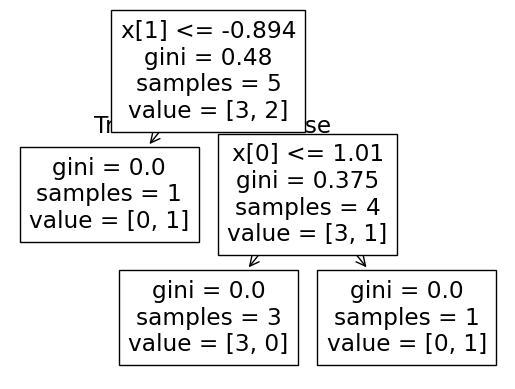

In [64]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [65]:
clf.feature_importances_

array([0.625, 0.375])

In [66]:
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X,y)

RandomForestClassifier(n_estimators=5)

In [67]:
rf.feature_importances_

array([0.48333333, 0.51666667])

In [68]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)
print(rf.estimators_[2].feature_importances_)
print(rf.estimators_[3].feature_importances_)
print(rf.estimators_[4].feature_importances_)

[0. 1.]
[0.41666667 0.58333333]
[0.625 0.375]
[1. 0.]
[0.375 0.625]
